In [1]:

path = '/home/apolo/Documents/github_projects/ripple_sync/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'


In [2]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import dabest

from statsmodels.stats.proportion import proportions_chisquare
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib widget

import helper_functions as hf


In [3]:

import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")


In [4]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [5]:
os.chdir(tables_path + '/figure_4/')

filename = 'Figure_Ripple_AmpAmpCoupling_RippleEpochs.csv'
df = pd.read_csv(filename)
df
shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df
# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df


,rat,session,side,shank_1,shank_2,shanks_distance,slope,intercept,r_value,p_value,std_err,shanks_distance_units
0,Ach,Achilles_10252013,ipsi,0,1,200.0,0.958530,0.011243,0.953788,0.0,0.002395,1.0
1,Ach,Achilles_10252013,ipsi,0,2,400.0,0.901941,0.027826,0.906202,0.0,0.003337,2.0
2,Ach,Achilles_10252013,ipsi,0,3,600.0,0.818832,0.058573,0.870209,0.0,0.003676,3.0
3,Ach,Achilles_10252013,ipsi,0,4,800.0,0.647936,0.087235,0.806110,0.0,0.003772,4.0
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,0.692199,0.135169,0.758620,0.0,0.004714,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
461,Gat,Gatsby_08282013,ipsi,12,14,400.0,1.004982,0.007291,0.910041,0.0,0.002628,2.0
462,Gat,Gatsby_08282013,ipsi,12,15,600.0,0.283855,0.033653,0.558273,0.0,0.002421,3.0
463,Gat,Gatsby_08282013,ipsi,13,14,200.0,0.989990,0.004686,0.932408,0.0,0.002203,1.0
464,Gat,Gatsby_08282013,ipsi,13,15,400.0,0.275885,0.033775,0.564353,0.0,0.002317,2.0


In [6]:

os.chdir(tables_path + '/figure_4/')

filename = 'Figure_Ripple_AmpAmpCoupling_WholeSignal.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]

shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]

# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)



,rat,session,side,shank_1,shank_2,shanks_distance,slope,intercept,r_value,p_value,std_err,shanks_distance_units
0,Ach,Achilles_10252013,ipsi,0,1,200.0,0.970992,0.034214,0.983326,0.0,0.000299,1.0
1,Ach,Achilles_10252013,ipsi,0,2,400.0,0.956902,0.051357,0.971062,0.0,0.000392,2.0
2,Ach,Achilles_10252013,ipsi,0,3,600.0,0.935805,0.085711,0.961695,0.0,0.000445,3.0
3,Ach,Achilles_10252013,ipsi,0,4,800.0,0.891310,0.156045,0.946675,0.0,0.000506,4.0
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,0.863237,0.197350,0.933385,0.0,0.000553,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
460,Gat,Gatsby_08282013,ipsi,12,14,400.0,1.050914,-0.107571,0.946526,0.0,0.000597,2.0
461,Gat,Gatsby_08282013,ipsi,12,15,600.0,0.808818,0.243535,0.881811,0.0,0.000721,3.0
462,Gat,Gatsby_08282013,ipsi,13,14,200.0,1.037970,-0.080108,0.959055,0.0,0.000511,1.0
463,Gat,Gatsby_08282013,ipsi,13,15,400.0,0.793447,0.270390,0.887434,0.0,0.000687,2.0


In [16]:
df.iloc[8]

rat                                    Ach
session                  Achilles_10252013
side                                contra
shank_1                                  0
shank_2                                  9
shanks_distance                      600.0
slope                             0.880584
intercept                         0.142323
r_value                           0.911388
p_value                                0.0
std_err                           0.000663
shanks_distance_units                  3.0
Name: 8, dtype: object

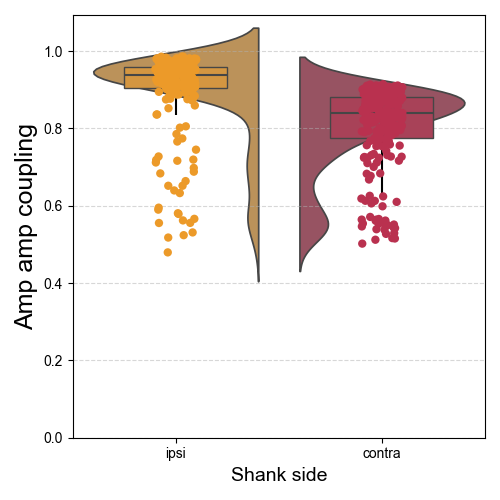

In [15]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="r_value", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)
# sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_abundance', order=["left", "right"],
#               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10)

# # Create the boxplot
box = sns.boxplot(data=df, x='side', hue="side", y='r_value',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='r_value',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1)

plt.ylabel('Amp amp coupling',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim(bottom=0)
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_4/')
fig_name = 'Figure_Ripple_AmpAmpCoupling_WholeSignal.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)


In [16]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "r_value ~ C(side, Treatment(reference='ipsi'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                          Mixed Linear Model Regression Results
Model:                        MixedLM             Dependent Variable:             r_value 
No. Observations:             465                 Method:                         REML    
No. Groups:                   4                   Scale:                          0.0058  
Min. group size:              36                  Log-Likelihood:                 518.8404
Max. group size:              198                 Converged:                      Yes     
Mean group size:              116.2                                                       
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       0.881    0.046  19.229 0.000  0.792  0.971
C(side, Treatment(referenc

/home/apolo/.pyenv/versions/3.12.7/envs/ripple_sync/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [10]:
result.pvalues

Intercept                                         2.102309e-82
C(side, Treatment(reference='ipsi'))[T.contra]    9.523125e-44
rat Var                                           2.307315e-01
session Var                                       3.607297e-01
dtype: float64

In [17]:
# Print summary of the model
print('coeff coefficient = ' + str(result.fe_params["C(side, Treatment(reference='ipsi'))[T.contra]"]))
print('coeff in % of intercept = ' + str(100*(result.fe_params["C(side, Treatment(reference='ipsi'))[T.contra]"]/result.fe_params['Intercept'])) + ' %')


coeff coefficient = -0.09875602685836118
coeff in % of intercept = -11.203605289759054 %


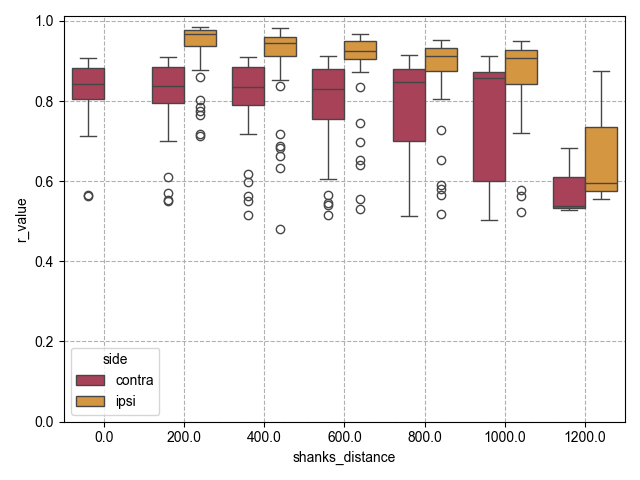

ClipPath elements not found.


In [11]:

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

plt.close('all')
sns.boxplot(data=df,x='shanks_distance',y='r_value',hue='side',palette=my_pal)
plt.ylim(bottom=0)
plt.grid(ls='--')
plt.tight_layout()

os.chdir(figures_path + '/figure_4/')
# fig_name = 'Figure_Ripple_AmpAmpCoupling_WholeSignal_ShankDistance.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
hf.delete_clip_path(fig_name)


In [12]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "r_value ~ C(side, Treatment(reference='ipsi')) * shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                                     Mixed Linear Model Regression Results
Model:                                MixedLM                    Dependent Variable:                    r_value 
No. Observations:                     465                        Method:                                REML    
No. Groups:                           4                          Scale:                                 0.0051  
Min. group size:                      36                         Log-Likelihood:                        540.4217
Max. group size:                      198                        Converged:                             Yes     
Mean group size:                      116.2                                                                     
----------------------------------------------------------------------------------------------------------------
                                                                     Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [15]:
result.pvalues

Intercept                                                               1.144432e-96
C(side, Treatment(reference='ipsi'))[T.contra]                          3.316442e-30
shanks_distance_units                                                   7.125333e-14
C(side, Treatment(reference='ipsi'))[T.contra]:shanks_distance_units    2.296830e-04
rat Var                                                                 2.300816e-01
session Var                                                             3.539810e-01
dtype: float64

In [18]:
import statsmodels.api as sm
data_ipsi = df[df['side'] == 'ipsi']

# Define the formula for the mixed-effects model
formula = "r_value ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_ipsi,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')


             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    r_value 
No. Observations:     220        Method:                REML    
No. Groups:           4          Scale:                 0.0052  
Min. group size:      22         Log-Likelihood:        249.6359
Max. group size:      90         Converged:             Yes     
Mean group size:      55.0                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.961    0.045 21.546 0.000  0.874  1.049
shanks_distance_units -0.028    0.004 -7.671 0.000 -0.036 -0.021
rat Var                0.007    0.086                           
session Var            0.000    0.004                           

shanks_distance_units coefficient = -0.0283515554562941
shanks_distance_units in % of intercept = -2.94

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [20]:
result.pvalues

Intercept                5.774445e-103
shanks_distance_units     1.707168e-14
rat Var                   2.358040e-01
session Var               5.347552e-01
dtype: float64

In [21]:
import statsmodels.api as sm
data_contra = df[df['side'] == 'contra']

# Define the formula for the mixed-effects model
formula = "r_value ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_contra,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')


             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    r_value 
No. Observations:     245        Method:                REML    
No. Groups:           4          Scale:                 0.0037  
Min. group size:      14         Log-Likelihood:        320.8923
Max. group size:      108        Converged:             Yes     
Mean group size:      61.2                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.783    0.059 13.175 0.000  0.667  0.900
shanks_distance_units -0.010    0.003 -3.927 0.000 -0.015 -0.005
rat Var                0.014    0.189                           
session Var            0.000    0.002                           

shanks_distance_units coefficient = -0.01016631463223823
shanks_distance_units in % of intercept = -1.2

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [23]:
result.pvalues

Intercept                1.227315e-39
shanks_distance_units    8.584959e-05
rat Var                  2.289273e-01
session Var              5.711138e-01
dtype: float64

In [18]:

os.chdir(tables_path + '/figure_4/')

filename = 'Figure_Ripple_CrossCorrelation_AmpEnv.csv'
df = pd.read_csv(filename)
df = df[df['shanks_distance'] != 1400]
df
shank_mask = (df['shank_1'] == 8) | (df['shank_1'] == 10) | (df['shank_2'] == 8) | (df['shank_2'] == 10)
rat_mask = df['rat'] == 'Bud'
df = df[~(shank_mask*rat_mask)]
df

df
# Do this to use in the linear mixed model formula with varying intercepts
# (i.e., 1|session, meaning that each session contains its own baseline, similar to paired data)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shanks_distance']/200
df = df.reset_index(drop=True)
df


,rat,session,side,shank_1,shank_2,shanks_distance,max_correlation,shanks_distance_units
0,Ach,Achilles_10252013,ipsi,0,1,200.0,8.648766e+06,1.0
1,Ach,Achilles_10252013,ipsi,0,2,400.0,8.395615e+06,2.0
2,Ach,Achilles_10252013,ipsi,0,3,600.0,8.194375e+06,3.0
3,Ach,Achilles_10252013,ipsi,0,4,800.0,7.936532e+06,4.0
4,Ach,Achilles_10252013,ipsi,0,5,1000.0,7.731520e+06,5.0
...,...,...,...,...,...,...,...,...
460,Gat,Gatsby_08282013,ipsi,12,14,400.0,8.353482e+06,2.0
461,Gat,Gatsby_08282013,ipsi,12,15,600.0,7.873699e+06,3.0
462,Gat,Gatsby_08282013,ipsi,13,14,200.0,8.445842e+06,1.0
463,Gat,Gatsby_08282013,ipsi,13,15,400.0,7.881835e+06,2.0


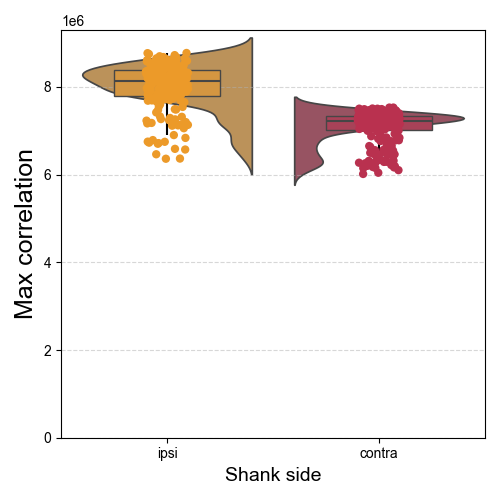

In [19]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df,hue='side', x="side",y="max_correlation", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=1)
# sns.pointplot(data=df,x='shank_side',hue="shank_side",y='ripple_abundance', order=["left", "right"],
#               estimator='median',errorbar=("pi",50), palette=my_pal,capsize=0, linestyle='none',
#               err_kws={'linewidth': 6},linewidth=2,markersize=10)

# # Create the boxplot
box = sns.boxplot(data=df, x='side', hue="side", y='max_correlation',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal,legend=False)  # Using the custom color palette

sns.violinplot(data=df,x='side', hue="side",order=["ipsi", "contra"], y='max_correlation',
               palette=my_pal,fill=True,inner = None,split=True,
               legend=False,density_norm='width',saturation=0.5,bw_adjust=1)

plt.ylabel('Max correlation',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.ylim(bottom=0)
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

os.chdir(figures_path + '/figure_4/')
fig_name = 'Figure_Ripple_CrossCorrelation_AmpEnv.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



In [20]:

import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "max_correlation ~ C(side, Treatment(reference='ipsi'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                                      Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 max_correlation  
No. Observations:                   465                     Method:                             REML             
No. Groups:                         4                       Scale:                              125642622568.5504
Min. group size:                    36                      Log-Likelihood:                     -6587.2191       
Max. group size:                    198                     Converged:                          Yes              
Mean group size:                    116.2                                                                        
-----------------------------------------------------------------------------------------------------------------
                                                    Coef.        Std.Err.     z    P>|z|    [0.025       0.975]  
------------

In [21]:
result.pvalues

Intercept                                          0.000000e+00
C(side, Treatment(reference='ipsi'))[T.contra]    9.950013e-181
rat Var                                            2.352844e-01
session Var                                        3.839761e-01
dtype: float64

In [22]:
# Print summary of the model
print('coeff coefficient = ' + str(result.fe_params["C(side, Treatment(reference='ipsi'))[T.contra]"]))
print('coeff in % of intercept = ' + str(100*(result.fe_params["C(side, Treatment(reference='ipsi'))[T.contra]"]/result.fe_params['Intercept'])) + ' %')


coeff coefficient = -947099.3875612966
coeff in % of intercept = -11.935778485083915 %


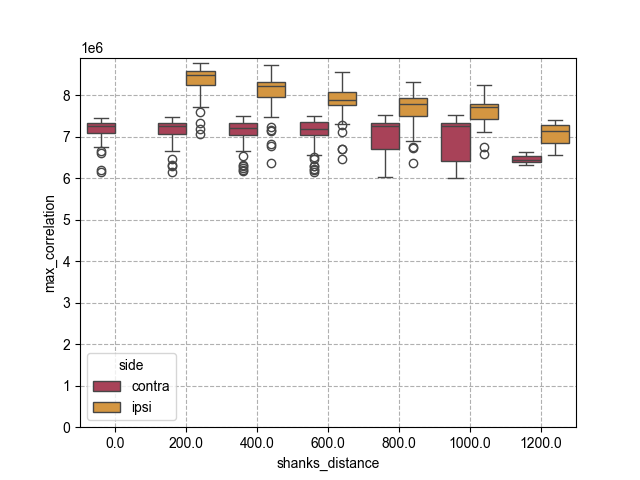

In [16]:
my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

plt.close('all')
sns.boxplot(data=df,hue='side',x='shanks_distance',y='max_correlation',palette=my_pal)
plt.grid(ls = '--')
plt.ylim(bottom=0)

os.chdir(figures_path + '/figure_4/')
fig_name = 'Figure_Ripple_CrossCorrelation_AmpEnv_ShankDistance.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



In [17]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "max_correlation ~ C(side, Treatment(reference='ipsi')) * shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                                                 Mixed Linear Model Regression Results
Model:                                     MixedLM                         Dependent Variable:                         max_correlation 
No. Observations:                          465                             Method:                                     REML            
No. Groups:                                4                               Scale:                                      85666635004.0050
Min. group size:                           36                              Log-Likelihood:                             -6477.7921      
Max. group size:                           198                             Converged:                                  Yes             
Mean group size:                           116.2                                                                                       
-------------------------------------------------------------------------------------------------

In [18]:
result.pvalues

Intercept                                                                0.000000e+00
C(side, Treatment(reference='ipsi'))[T.contra]                          1.040457e-163
shanks_distance_units                                                    1.309777e-47
C(side, Treatment(reference='ipsi'))[T.contra]:shanks_distance_units     3.963146e-22
rat Var                                                                  2.355429e-01
session Var                                                              3.019434e-01
dtype: float64

In [20]:
import statsmodels.api as sm
data_ipsi = df[df['side'] == 'ipsi']

# Define the formula for the mixed-effects model
formula = "max_correlation ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_ipsi,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')
result.pvalues

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                        Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        max_correlation  
No. Observations:          220            Method:                    REML             
No. Groups:                4              Scale:                     113540745714.1824
Min. group size:           22             Log-Likelihood:            -3099.0585       
Max. group size:           90             Converged:                 Yes              
Mean group size:           55.0                                                       
--------------------------------------------------------------------------------------
                           Coef.       Std.Err.     z    P>|z|    [0.025      0.975]  
--------------------------------------------------------------------------------------
Intercept                 8505805.710 138191.018  61.551 0.000 8234956.292 8776655.128
shanks_distance_units     -219395.896  17187.533 -12.765 0.000 -2530

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


Intercept                0.000000e+00
shanks_distance_units    2.577205e-37
rat Var                  1.801273e-01
session Var                       NaN
dtype: float64

In [21]:
import statsmodels.api as sm
data_contra = df[df['side'] == 'contra']

# Define the formula for the mixed-effects model
formula = "max_correlation ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_contra,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')
result.pvalues

                        Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         max_correlation 
No. Observations:         245             Method:                     REML            
No. Groups:               4               Scale:                      40705590540.7431
Min. group size:          14              Log-Likelihood:             -3330.3554      
Max. group size:          108             Converged:                  Yes             
Mean group size:          61.2                                                        
--------------------------------------------------------------------------------------
                           Coef.        Std.Err.    z    P>|z|    [0.025      0.975]  
--------------------------------------------------------------------------------------
Intercept                  6981566.246 218020.337 32.023 0.000 6554254.238 7408878.255
shanks_distance_units       -30720.163   8591.983 -3.575 0.000  -475

Intercept                5.294766e-225
shanks_distance_units     3.496328e-04
rat Var                   2.369781e-01
session Var               2.604806e-01
dtype: float64